In [110]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
style.use('ggplot')

In [111]:
tiempo_estandar = pd.read_csv("./tiempo_estandar.csv")
tiempo_estandar

,agencia,tipo_ope,t_p,t_n,t_s
0,AG.PARQUE DE LAS FLORES LOS GUINDALES,DEPOSITO,2.80,2.90,2.98
1,AG.PARQUE DE LAS FLORES LOS GUINDALES,COBRANZA LOCALES OTRAS AGENCIAS,2.61,2.74,2.80
2,AG.PARQUE DE LAS FLORES LOS GUINDALES,COBRANZAS,2.61,2.80,2.98
3,AG.PARQUE DE LAS FLORES LOS GUINDALES,RETIRO,2.55,2.66,2.84
4,AG.PARQUE DE LAS FLORES LOS GUINDALES,DESEMBOLSO,17.22,18.00,20.03
5,AG.PARQUE DE LAS FLORES LOS GUINDALES,APERTURA,4.00,4.30,4.89
6,AG. CIUDAD UNIVERSITARIA,DEPOSITO,2.50,2.60,2.80
7,AG. CIUDAD UNIVERSITARIA,COBRANZA LOCALES OTRAS AGENCIAS,2.60,2.70,2.99
8,AG. CIUDAD UNIVERSITARIA,COBRANZAS,2.58,2.62,2.89
9,AG. CIUDAD UNIVERSITARIA,RETIRO,2.59,2.62,2.88


In [112]:
distribucion = pd.read_csv("./dist_agencias.csv")
distribucion

,agencia,tipo_ope,09:00:00 - 09:59:59,10:00:00 - 10:59:59,11:00:00 - 11:59:59,12:00:00 - 12:59:59,13:00:00 - 13:59:59,14:00:00 - 14:59:59,15:00:00 - 15:59:59,16:00:00 - 16:59:59,17:00:00 - 17:59:59,18:00:00 - 18:59:59
0,AG. CIUDAD UNIVERSITARIA,DEPOSITO,0.4180,0.4114,0.4165,0.4278,0.4257,0.4599,0.4308,0.3692,0.3058,0.2372
1,AG. CIUDAD UNIVERSITARIA,COBRANZA LOCALES OTRAS AGENCIAS,0.1506,0.1444,0.1497,0.1511,0.1673,0.1730,0.1785,0.1815,0.1784,0.1439
2,AG. CIUDAD UNIVERSITARIA,COBRANZAS,0.1048,0.1048,0.0972,0.0970,0.0979,0.0921,0.0957,0.1167,0.1391,0.1537
3,AG. CIUDAD UNIVERSITARIA,RETIRO,0.1809,0.1619,0.1583,0.1593,0.1902,0.1615,0.1546,0.1438,0.1265,0.1675
4,AG. CIUDAD UNIVERSITARIA,DESEMBOLSO,0.0296,0.0350,0.0374,0.0431,0.0473,0.0403,0.0341,0.0413,0.0684,0.1150
5,AG. CIUDAD UNIVERSITARIA,APERTURA,0.0388,0.0372,0.0439,0.0446,0.0497,0.0504,0.0428,0.0431,0.0362,0.0727
6,AG.PARQUE DE LAS FLORES LOS GUINDALES,DEPOSITO,0.3560,0.3570,0.3569,0.3581,0.3474,0.3670,0.3881,0.3595,0.3048,0.2337
7,AG.PARQUE DE LAS FLORES LOS GUINDALES,COBRANZA LOCALES OTRAS AGENCIAS,0.1771,0.1618,0.1615,0.1729,0.1873,0.2064,0.1898,0.1880,0.1877,0.1572
8,AG.PARQUE DE LAS FLORES LOS GUINDALES,COBRANZAS,0.2339,0.2097,0.2002,0.1973,0.2685,0.2180,0.1925,0.1749,0.1602,0.2248
9,AG.PARQUE DE LAS FLORES LOS GUINDALES,RETIRO,0.0941,0.0952,0.0995,0.0970,0.0924,0.0875,0.0875,0.1053,0.1253,0.1588


In [113]:
distribucion_t = distribucion.merge(tiempo_estandar, on=["agencia", "tipo_ope"], how="inner")
distribucion_t

,agencia,tipo_ope,09:00:00 - 09:59:59,10:00:00 - 10:59:59,11:00:00 - 11:59:59,12:00:00 - 12:59:59,13:00:00 - 13:59:59,14:00:00 - 14:59:59,15:00:00 - 15:59:59,16:00:00 - 16:59:59,17:00:00 - 17:59:59,18:00:00 - 18:59:59,t_p,t_n,t_s
0,AG. CIUDAD UNIVERSITARIA,DEPOSITO,0.4180,0.4114,0.4165,0.4278,0.4257,0.4599,0.4308,0.3692,0.3058,0.2372,2.50,2.60,2.80
1,AG. CIUDAD UNIVERSITARIA,COBRANZA LOCALES OTRAS AGENCIAS,0.1506,0.1444,0.1497,0.1511,0.1673,0.1730,0.1785,0.1815,0.1784,0.1439,2.60,2.70,2.99
2,AG. CIUDAD UNIVERSITARIA,COBRANZAS,0.1048,0.1048,0.0972,0.0970,0.0979,0.0921,0.0957,0.1167,0.1391,0.1537,2.58,2.62,2.89
3,AG. CIUDAD UNIVERSITARIA,RETIRO,0.1809,0.1619,0.1583,0.1593,0.1902,0.1615,0.1546,0.1438,0.1265,0.1675,2.59,2.62,2.88
4,AG. CIUDAD UNIVERSITARIA,DESEMBOLSO,0.0296,0.0350,0.0374,0.0431,0.0473,0.0403,0.0341,0.0413,0.0684,0.1150,18.00,18.50,20.30
5,AG. CIUDAD UNIVERSITARIA,APERTURA,0.0388,0.0372,0.0439,0.0446,0.0497,0.0504,0.0428,0.0431,0.0362,0.0727,4.10,4.30,4.89
6,AG.PARQUE DE LAS FLORES LOS GUINDALES,DEPOSITO,0.3560,0.3570,0.3569,0.3581,0.3474,0.3670,0.3881,0.3595,0.3048,0.2337,2.80,2.90,2.98
7,AG.PARQUE DE LAS FLORES LOS GUINDALES,COBRANZA LOCALES OTRAS AGENCIAS,0.1771,0.1618,0.1615,0.1729,0.1873,0.2064,0.1898,0.1880,0.1877,0.1572,2.61,2.74,2.80
8,AG.PARQUE DE LAS FLORES LOS GUINDALES,COBRANZAS,0.2339,0.2097,0.2002,0.1973,0.2685,0.2180,0.1925,0.1749,0.1602,0.2248,2.61,2.80,2.98
9,AG.PARQUE DE LAS FLORES LOS GUINDALES,RETIRO,0.0941,0.0952,0.0995,0.0970,0.0924,0.0875,0.0875,0.1053,0.1253,0.1588,2.55,2.66,2.84


In [114]:
df = pd.read_csv("./df.csv")
df

,agencia,hora,lambda,servidores,Cs,Cq
0,AG.PARQUE DE LAS FLORES LOS GUINDALES,09:00:00 - 09:59:59,50.50,5,13.64,27.29
1,AG.PARQUE DE LAS FLORES LOS GUINDALES,10:00:00 - 10:59:59,60.12,5,13.64,27.29
2,AG.PARQUE DE LAS FLORES LOS GUINDALES,11:00:00 - 11:59:59,58.90,5,13.64,27.29
3,AG.PARQUE DE LAS FLORES LOS GUINDALES,12:00:00 - 12:59:59,43.48,5,13.64,27.29
4,AG.PARQUE DE LAS FLORES LOS GUINDALES,13:00:00 - 13:59:59,35.00,5,13.64,27.29
5,AG.PARQUE DE LAS FLORES LOS GUINDALES,14:00:00 - 14:59:59,31.64,5,13.64,27.29
6,AG.PARQUE DE LAS FLORES LOS GUINDALES,15:00:00 - 15:59:59,44.23,5,13.64,27.29
7,AG.PARQUE DE LAS FLORES LOS GUINDALES,16:00:00 - 16:59:59,59.11,5,13.64,27.29
8,AG.PARQUE DE LAS FLORES LOS GUINDALES,17:00:00 - 17:59:59,65.28,5,13.64,27.29
9,AG.PARQUE DE LAS FLORES LOS GUINDALES,18:00:00 - 18:59:59,23.45,5,13.64,27.29


In [115]:
def calcular_mu(distribucion_t: pd.DataFrame, cols_horas: list) -> pd.Series:
    """
    Calcula μ (clientes por hora) de forma 100% vectorizada y escalable.
    Usa melt + groupby.sum() → extremadamente rápido incluso con millones de filas en distribucion_t.
    """
    # Preparamos datos largos (melt es muy eficiente en pandas)
    probs_long = distribucion_t[['agencia', 't_s'] + cols_horas].copy()
    probs_long[cols_horas] = probs_long[cols_horas].astype(float)
    probs_long['t_s'] = probs_long['t_s'].astype(float)

    probs_long = probs_long.melt(
        id_vars=['agencia', 't_s'],
        value_vars=cols_horas,
        var_name='hora',
        value_name='prob'
    )

    # Cálculo vectorizado (la fórmula se simplifica a: μ = 60 * Σp / Σ(p·t))
    probs_long['p_t'] = probs_long['prob'] * probs_long['t_s']

    grouped = probs_long.groupby(['agencia', 'hora'], sort=False)
    sum_p = grouped['prob'].sum()
    sum_p_t = grouped['p_t'].sum()

    mu_series = 60 * sum_p / sum_p_t
    mu_series.name = 'mu'
    return mu_series

In [116]:
from scipy.special import factorial
from scipy.stats import poisson

def calcular_metricas(
    df: pd.DataFrame,
    col_lam: str = 'lambda',
    col_mu: str = 'mu',
    col_c: str = 'servidores',
    col_Cs: str = 'Cs',
    col_Cq: str = 'Cq'
) -> pd.DataFrame:
    """
    Calcula las 14 métricas M/M/c de forma 100% vectorizada con NumPy + SciPy.
    - Usa poisson.cdf + factorial vectorizados → mucho más rápido que bucles o .apply().
    - Maneja automáticamente casos inválidos (ρ ≥ 1, μ ≤ 0, etc.) con NaN.
    - Escalable a millones de filas en segundos.
    """
    lam = df[col_lam].values.astype(float)
    mu = df[col_mu].values.astype(float)
    c = df[col_c].values.astype(float)      # lo tratamos como float para seguridad
    Cs = df[col_Cs].values.astype(float)
    Cq = df[col_Cq].values.astype(float)

    n = len(df)
    
    # Rho siempre calculado (mejora vs versión original)
    rho = np.where((c > 0) & (mu > 0), lam / (c * mu), np.nan)
    
    # Máscara de casos válidos (ρ < 1)
    mask = (rho < 1) & np.isfinite(rho)
    
    # Arrays de salida inicializados en NaN
    P0 = np.full(n, np.nan)
    Lq = np.full(n, np.nan)
    Wq_h = np.full(n, np.nan)
    
    # Cálculo vectorizado solo en casos válidos
    if np.any(mask):
        r_mask = lam[mask] / mu[mask]
        c_mask = c[mask].astype(int)          # factorial requiere int
        rho_mask = rho[mask]
        
        # Suma de Poisson: Σ (r^k / k!) desde k=0 hasta c-1
        sum_k = np.exp(r_mask) * poisson.cdf(c_mask - 1, r_mask)
        
        # Factorial(c)
        fact_c = factorial(c_mask, exact=False)
        
        # Término final
        term_final = (r_mask ** c_mask) / (fact_c * (1 - rho_mask))
        
        denom = sum_k + term_final
        P0[mask] = 1 / denom
        
        # Lq
        Lq[mask] = P0[mask] * (r_mask ** c_mask) * rho_mask / (fact_c * (1 - rho_mask) ** 2)
    
    # Métricas restantes (propagación automática de NaN)
    Wq_h = np.divide(Lq, lam, out=np.full(n, np.nan), where=lam>0)
    Ws_h = Wq_h + np.divide(1.0, mu, out=np.full(n, np.nan), where=mu>0)
    Ls = lam * Ws_h
    Wq_m = Wq_h * 60
    Ws_m = Ws_h * 60
    
    servidores_ocupados = Ls - Lq
    servidores_ociosos = c - servidores_ocupados
    
    CTS = (Cs + Cq) * servidores_ocupados
    CTS_idle = Cs * servidores_ociosos
    CTQ = lam * Cq * Wq_h
    CT = CTS + CTS_idle + CTQ
    
    # DataFrame de resultados (mantiene el índice original de df)
    metrics = pd.DataFrame({
        'rho': rho,
        'P0': P0,
        'Lq': Lq,
        'Wq_h': Wq_h,
        'Ws_h': Ws_h,
        'Ls': Ls,
        'Wq_m': Wq_m,
        'Ws_m': Ws_m,
        'servidores_ocupados': servidores_ocupados,
        'servidores_ociosos': servidores_ociosos,
        'CTS': CTS,
        'CTS_idle': CTS_idle,
        'CTQ': CTQ,
        'CT': CT
    }, index=df.index)
    
    return metrics

In [117]:
from typing import Optional, Tuple
import numpy as np
import pandas as pd

def servidores_optimos(
    lam: float,
    mu: float,
    Cs: float,
    Cq: float,
    umbral_wq_m: float = 5.0,
    rho_max: float = 0.85,
    c_max: int = 20
) -> Tuple:

    c_values = np.arange(1, c_max + 1)

    df_tmp = pd.DataFrame({
        "lambda": np.full(c_max, lam),
        "mu": np.full(c_max, mu),
        "servidores": c_values,
        "Cs": np.full(c_max, Cs),
        "Cq": np.full(c_max, Cq)
    })

    metrics = calcular_metricas(df_tmp)

    rho = metrics["rho"].to_numpy()
    Wq_m = metrics["Wq_m"].to_numpy()

    mask = (rho < rho_max) & (Wq_m <= umbral_wq_m)

    if not mask.any():
        return (None,) * 15

    idx = np.argmax(mask)

    return (c_values[idx], *metrics.iloc[idx].tolist())

In [118]:
cols_horas = distribucion_t.columns[2:12].tolist()   # tus columnas de horas

mu_series = calcular_mu(distribucion_t, cols_horas)
df = df.merge(
    mu_series.reset_index(),
    on=['agencia', 'hora'],
    how='left'
)

df

,agencia,hora,lambda,servidores,Cs,Cq,mu
0,AG.PARQUE DE LAS FLORES LOS GUINDALES,09:00:00 - 09:59:59,50.50,5,13.64,27.29,16.949576
1,AG.PARQUE DE LAS FLORES LOS GUINDALES,10:00:00 - 10:59:59,60.12,5,13.64,27.29,16.283563
2,AG.PARQUE DE LAS FLORES LOS GUINDALES,11:00:00 - 11:59:59,58.90,5,13.64,27.29,16.019559
3,AG.PARQUE DE LAS FLORES LOS GUINDALES,12:00:00 - 12:59:59,43.48,5,13.64,27.29,15.498358
4,AG.PARQUE DE LAS FLORES LOS GUINDALES,13:00:00 - 13:59:59,35.00,5,13.64,27.29,15.832397
5,AG.PARQUE DE LAS FLORES LOS GUINDALES,14:00:00 - 14:59:59,31.64,5,13.64,27.29,15.973582
6,AG.PARQUE DE LAS FLORES LOS GUINDALES,15:00:00 - 15:59:59,44.23,5,13.64,27.29,16.680594
7,AG.PARQUE DE LAS FLORES LOS GUINDALES,16:00:00 - 16:59:59,59.11,5,13.64,27.29,16.139607
8,AG.PARQUE DE LAS FLORES LOS GUINDALES,17:00:00 - 17:59:59,65.28,5,13.64,27.29,14.327388
9,AG.PARQUE DE LAS FLORES LOS GUINDALES,18:00:00 - 18:59:59,23.45,5,13.64,27.29,11.495246


In [119]:
df_metrics = calcular_metricas(df)

df = pd.concat([df, df_metrics], axis=1)
df.columns

Index(['agencia', 'hora', 'lambda', 'servidores', 'Cs', 'Cq', 'mu', 'rho',
       'P0', 'Lq', 'Wq_h', 'Ws_h', 'Ls', 'Wq_m', 'Ws_m', 'servidores_ocupados',
       'servidores_ociosos', 'CTS', 'CTS_idle', 'CTQ', 'CT'],
      dtype='object')

In [120]:

resultados = df.apply(
    lambda r: servidores_optimos(
        lam=r["lambda"],
        mu=r["mu"],
        Cs=r["Cs"],
        Cq=r["Cq"]
    ),
    axis=1
)

cols = [
    "c_opt",
    "rho_opt",
    "P0_opt",
    "Lq_opt",
    "Wq_h_opt",
    "Ws_h_opt",
    "Ls_opt",
    "Wq_m_opt",
    "Ws_m_opt",
    "s_ocup_opt",
    "s_idle_opt",
    "CTS_opt",
    "CTS_idle_opt",
    "CTQ_opt",
    "CT_opt"
]

df_resultados = pd.DataFrame(resultados.tolist(), columns=cols, index=df.index)

df = pd.concat([df, df_resultados], axis=1)

df

,agencia,hora,lambda,servidores,Cs,Cq,mu,rho,P0,Lq,...,Ws_h_opt,Ls_opt,Wq_m_opt,Ws_m_opt,s_ocup_opt,s_idle_opt,CTS_opt,CTS_idle_opt,CTQ_opt,CT_opt
0,AG.PARQUE DE LAS FLORES LOS GUINDALES,09:00:00 - 09:59:59,50.50,5,13.64,27.29,16.949576,0.595885,0.047731,0.340748,...,0.087951,4.441533,1.737158,5.277069,2.979426,1.020574,121.947889,13.920635,39.900923,175.769448
1,AG.PARQUE DE LAS FLORES LOS GUINDALES,10:00:00 - 10:59:59,60.12,5,13.64,27.29,16.283563,0.738413,0.020205,1.246497,...,0.082145,4.938564,1.244009,4.928707,3.692067,1.307933,151.116292,17.840209,34.016908,202.973410
2,AG.PARQUE DE LAS FLORES LOS GUINDALES,11:00:00 - 11:59:59,58.90,5,13.64,27.29,16.019559,0.735351,0.020622,1.212332,...,0.083007,4.889087,1.234973,4.980395,3.676755,1.323245,150.489595,18.049057,33.084544,201.623197
3,AG.PARQUE DE LAS FLORES LOS GUINDALES,12:00:00 - 12:59:59,43.48,5,13.64,27.29,15.498358,0.561092,0.057798,0.243803,...,0.087791,3.817158,1.396090,5.267468,2.805459,1.194541,114.827418,16.293546,27.609288,158.730252
4,AG.PARQUE DE LAS FLORES LOS GUINDALES,13:00:00 - 13:59:59,35.00,5,13.64,27.29,15.832397,0.442131,0.108242,0.067657,...,0.106978,3.744217,2.628960,6.418658,2.210657,0.789343,90.482195,10.766637,41.850857,143.099689
5,AG.PARQUE DE LAS FLORES LOS GUINDALES,14:00:00 - 14:59:59,31.64,5,13.64,27.29,15.973582,0.396154,0.136988,0.037817,...,0.089350,2.827044,1.604817,5.361019,1.980770,1.019230,81.072934,13.902291,23.094803,118.070028
6,AG.PARQUE DE LAS FLORES LOS GUINDALES,15:00:00 - 15:59:59,44.23,5,13.64,27.29,16.680594,0.530317,0.068215,0.179123,...,0.076530,3.384916,0.994799,4.591793,2.651584,1.348416,108.529340,18.392392,20.012639,146.934371
7,AG.PARQUE DE LAS FLORES LOS GUINDALES,16:00:00 - 16:59:59,59.11,5,13.64,27.29,16.139607,0.732484,0.021018,1.181240,...,0.081943,4.843658,1.199025,4.916588,3.662419,1.337581,149.902798,18.244609,32.236026,200.383433
8,AG.PARQUE DE LAS FLORES LOS GUINDALES,17:00:00 - 17:59:59,65.28,5,13.64,27.29,14.327388,0.911262,0.004272,8.090427,...,0.091016,5.941497,1.273151,5.460934,4.556309,1.443691,186.489710,19.691951,37.801785,243.983446
9,AG.PARQUE DE LAS FLORES LOS GUINDALES,18:00:00 - 18:59:59,23.45,5,13.64,27.29,11.495246,0.407995,0.128958,0.044197,...,0.128979,3.024567,2.519215,7.738765,2.039974,0.960026,83.496128,13.094757,26.869553,123.460438


KeyError: 'Wq_m_o'

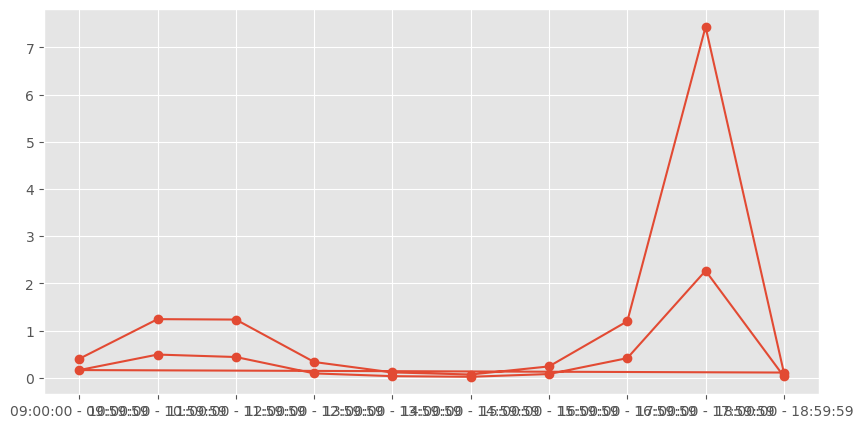

In [121]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(df["hora"], df["Wq_m"], marker="o", label="Espera actual (min)")
plt.plot(df["hora"], df["Wq_m_o"], marker="o", label="Espera óptima (min)")

plt.plot(df["hora"], df["CT"], marker="s", linestyle="--", label="Costo actual")
plt.plot(df["hora"], df["CT_o"], marker="s", linestyle="--", label="Costo óptimo")

plt.xlabel("Hora")
plt.ylabel("Valor")
plt.title("Trade-off entre tiempo de espera y costo")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
import simpy
import random
import numpy as np

def simular_agencia(lam, mu, ventanillas, tiempo_sim=480):

    esperas = []

    def cliente(env, ventanillas):

        llegada = env.now

        with ventanillas.request() as req:
            yield req

            espera = env.now - llegada
            esperas.append(espera)

            servicio = random.expovariate(mu)
            yield env.timeout(servicio)

    def generador(env, ventanillas):

        while True:
            yield env.timeout(random.expovariate(lam))
            env.process(cliente(env, ventanillas))

    env = simpy.Environment()
    recurso = simpy.Resource(env, capacity=ventanillas)

    env.process(generador(env, recurso))

    env.run(until=tiempo_sim)

    return {
        "clientes": len(esperas),
        "espera_promedio": np.mean(esperas),
        "p95": np.percentile(esperas,95)
    }

In [ ]:
simulaciones = []

for _, row in df.iterrows():

    lam = row["lambda"]/60
    mu = row["mu"]/60

    for v in range(2,10):

        resultado = simular_agencia(lam, mu, v)

        simulaciones.append({
            "hora": row["hora"],
            "ventanillas": v,
            "espera_promedio": resultado["espera_promedio"],
            "espera_p95": resultado["p95"],
            "clientes": resultado["clientes"]
        })

df_sim = pd.DataFrame(simulaciones)

df_sim

,hora,ventanillas,espera_promedio,espera_p95,clientes
0,09:00:00 - 09:59:59,2,0.0,0.0,2
1,09:00:00 - 09:59:59,3,0.0,0.0,2
2,09:00:00 - 09:59:59,4,0.0,0.0,2
3,09:00:00 - 09:59:59,5,0.0,0.0,2
4,09:00:00 - 09:59:59,6,0.0,0.0,2
...,...,...,...,...,...
155,18:00:00 - 18:59:59,5,0.0,0.0,2
156,18:00:00 - 18:59:59,6,0.0,0.0,2
157,18:00:00 - 18:59:59,7,0.0,0.0,2
158,18:00:00 - 18:59:59,8,0.0,0.0,2
